# Round 4 — VEV / VE options research

Companion to [`round4_options_research.md`](round4_options_research.md). One product family per file (L6) — only `VELVETFRUIT_EXTRACT` and `VEV_*` here. No hydrogel, no manual exotics.

## What we want to learn

1. **R3→R4 microstructure delta.** What changed? In particular: VE bid-ask blew up from 1 to 5 — does that kill any R3 strategy?
2. **The smile.** Confirm the flat-smile finding from R3 is still flat in R4, and quantify the per-strike IV.
3. **The Black-Scholes alpha.** Discord mod hinted at alpha in BS. Likely refers to the RV >> IV gap. Measure RV (two-scale, de-noised), measure IV, compute the gap.
4. **Counterparties on options.** Mark 01 / Mark 22 dominate the VEV tape — are they informed/passive (per VE drift after their prints)?
5. **Can we capture the gap?** Pathwise gamma-scalp simulation with realistic VE hedge cost. Hedge-band sweep.
6. **Per-strike spread + depth + fill rate** to know which strikes are tradeable.

Every conclusion must survive the hydrogel-research gates (L1–L7 of [`round4_research.md`](round4_research.md) §0): structural alpha, discrete thresholds, sizing first, no parameter sweeps on 3 days.

In [1]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm
from scipy.optimize import brentq

plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

DATA_DIR = '../dataset/ROUND_4'
DAYS = [1, 2, 3]
TTE_BY_DAY = {1: 7/365, 2: 6/365, 3: 5/365}  # historical maps; live R4 starts at 4d
STRIKES_ALL = [4000, 4500, 5000, 5100, 5200, 5300, 5400, 5500, 6000, 6500]
STRIKES_ATM = [5000, 5100, 5200, 5300, 5400, 5500]
STRIKES_TRADEABLE = [5200, 5300, 5400, 5500]  # see §1.2 of the .md

## 1. Load data

3 historical days × 30 000 ticks each. Long-format prices CSV (one row per (timestamp, product)) and trades CSV with counterparty IDs.

In [2]:
prices, trades = [], []
for d in DAYS:
    p = pd.read_csv(f'{DATA_DIR}/prices_round_4_day_{d}.csv', sep=';'); p['day'] = d
    t = pd.read_csv(f'{DATA_DIR}/trades_round_4_day_{d}.csv', sep=';'); t['day'] = d
    prices.append(p); trades.append(t)
P = pd.concat(prices, ignore_index=True)
T = pd.concat(trades, ignore_index=True)

S_df = (P[P['product'] == 'VELVETFRUIT_EXTRACT'][['day', 'timestamp', 'mid_price']]
        .rename(columns={'mid_price': 'S'})
        .sort_values(['day', 'timestamp'])
        .reset_index(drop=True))

print(f'P rows: {len(P):,}  |  T rows: {len(T):,}  |  products: {P["product"].nunique()}')
print(f'VE samples: {len(S_df):,}  |  per-day: {S_df.groupby("day").size().to_dict()}')

P rows: 360,000  |  T rows: 4,281  |  products: 12
VE samples: 30,000  |  per-day: {1: 10000, 2: 10000, 3: 10000}


## 2. VE underlying — path + spread

**Critical R3→R4 change.** R3 had VE bid-ask = 1 SeaShell. R4 has bid-ask = 5 SeaShells (median). This 5× hedge-cost inflation is the single biggest microstructure shift; it disqualifies tick-by-tick gamma scalping (see §5 below).

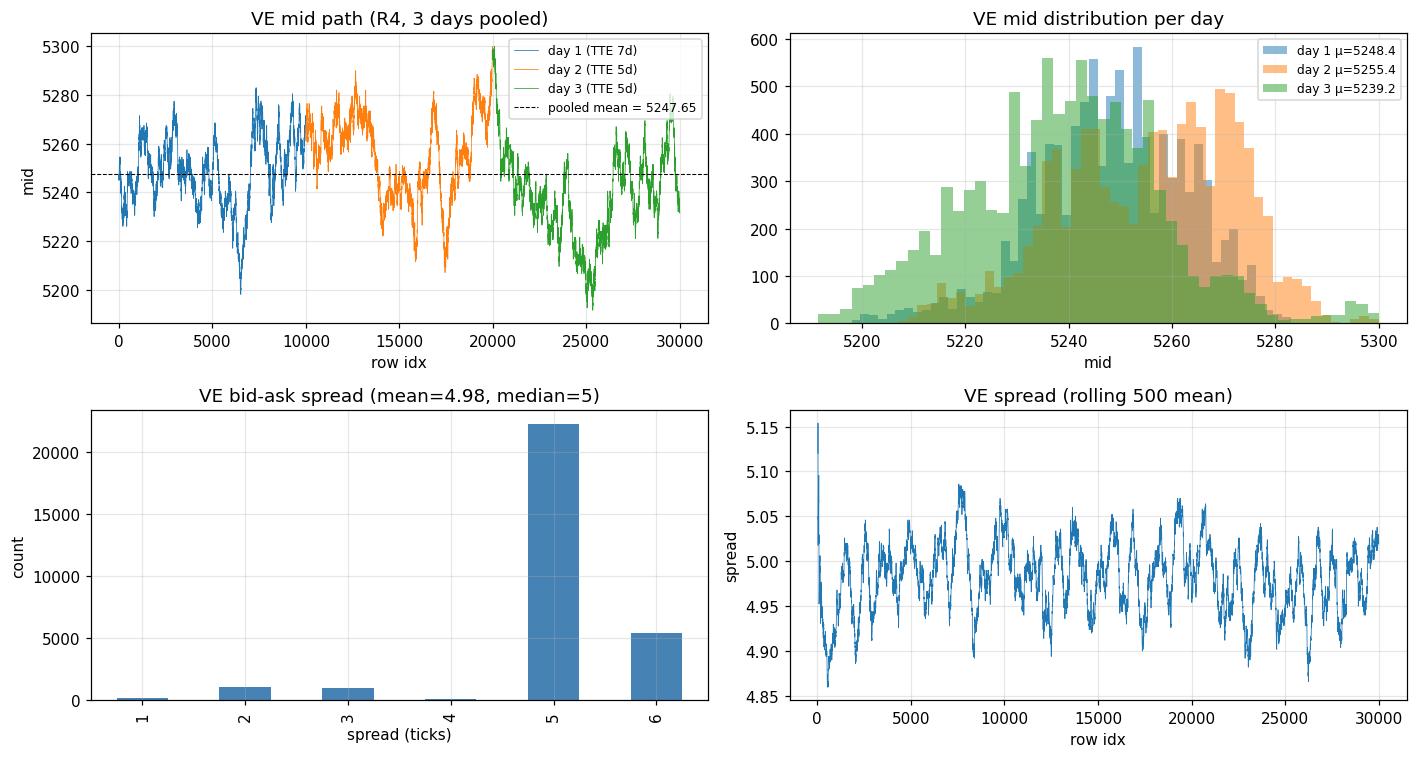

VE pooled: mean=5247.649, std=18.077, range=[5191.5, 5300.0]
VE spread: mean=4.982, median=5.0, max=6
Per-day VE means: {1: 5248.39, 2: 5255.39, 3: 5239.16}


In [3]:
VE = P[P['product'] == 'VELVETFRUIT_EXTRACT'].copy().sort_values(['day', 'timestamp']).reset_index(drop=True)
VE['spread'] = VE['ask_price_1'] - VE['bid_price_1']

fig, axes = plt.subplots(2, 2, figsize=(13, 7))

# Path
ax = axes[0, 0]
for d in DAYS:
    sub = VE[VE['day'] == d]
    ax.plot(sub.index, sub['mid_price'], lw=0.5, label=f'day {d} (TTE {int(TTE_BY_DAY[d]*365)}d)')
ax.axhline(VE['mid_price'].mean(), color='k', ls='--', lw=0.7, label=f"pooled mean = {VE['mid_price'].mean():.2f}")
ax.set_title('VE mid path (R4, 3 days pooled)')
ax.set_xlabel('row idx'); ax.set_ylabel('mid'); ax.legend(fontsize=8)

# Per-day mid hist
ax = axes[0, 1]
for d in DAYS:
    ax.hist(VE[VE['day'] == d]['mid_price'], bins=50, alpha=0.5, label=f'day {d} μ={VE[VE["day"]==d]["mid_price"].mean():.1f}')
ax.set_title('VE mid distribution per day'); ax.set_xlabel('mid'); ax.legend(fontsize=8)

# Spread distribution
ax = axes[1, 0]
VE['spread'].value_counts().sort_index().plot.bar(ax=ax, color='steelblue')
ax.set_title(f'VE bid-ask spread (mean={VE["spread"].mean():.2f}, median={VE["spread"].median():.0f})')
ax.set_xlabel('spread (ticks)'); ax.set_ylabel('count')

# Spread over time
ax = axes[1, 1]
VE_smooth = VE['spread'].rolling(500, min_periods=50).mean()
ax.plot(VE.index, VE_smooth, lw=0.5)
ax.set_title('VE spread (rolling 500 mean)'); ax.set_xlabel('row idx'); ax.set_ylabel('spread')

plt.tight_layout(); plt.show()

print(f"VE pooled: mean={VE['mid_price'].mean():.3f}, std={VE['mid_price'].std():.3f}, range=[{VE['mid_price'].min()}, {VE['mid_price'].max()}]")
print(f"VE spread: mean={VE['spread'].mean():.3f}, median={VE['spread'].median()}, max={VE['spread'].max()}")
print('Per-day VE means:', VE.groupby('day')['mid_price'].mean().round(2).to_dict())

## 3. Per-strike microstructure — spread, book depth, trade activity

Tradeable universe = strikes where (a) spread is small enough that we can quote inside, AND (b) there is real trade flow we can join. Both criteria narrow the live ladder to **5200, 5300, 5400, 5500**.

- 5000/5100: book quotes them but only 3 trades over 3 days. Effectively dead.
- 4000/4500: deep ITM, spread 16–21 ticks; pure intrinsic. R3 lost 9 k SS here.
- 6000/6500: floor-pegged at 0.5; the 317 prints/day occur at price 0 between Mark 01 ↔ Mark 22. Private giveaway flow.

In [4]:
rows = []
for K in STRIKES_ALL:
    sub = P[P['product'] == f'VEV_{K}'].copy()
    sub['sp'] = sub['ask_price_1'] - sub['bid_price_1']
    n_tr = (T['symbol'] == f'VEV_{K}').sum()
    rows.append({
        'K': K,
        'mid_mean': sub['mid_price'].mean(),
        'spread_mean': sub['sp'].mean(),
        'spread_med': sub['sp'].median(),
        'bid_v1_mean': sub['bid_volume_1'].mean(),
        'ask_v1_mean': sub['ask_volume_1'].mean(),
        'n_trades_3d': n_tr,
    })
micro = pd.DataFrame(rows).set_index('K')
micro

,mid_mean,spread_mean,spread_med,bid_v1_mean,ask_v1_mean,n_trades_3d
K,,,,,,
4000,1247.656550,20.753500,21.0,10.917733,10.911900,442
4500,747.656750,15.793833,16.0,8.952500,8.945167,3
5000,251.144583,5.964233,6.0,15.540767,15.666933,3
5100,160.863300,4.174400,4.0,19.554700,19.566533,3
5200,88.993483,2.757833,3.0,22.809700,22.808233,47
5300,41.176300,1.973067,2.0,20.512167,20.535533,164
5400,12.629783,1.304033,1.0,21.906533,21.875900,276
5500,4.707783,1.108767,1.0,22.276433,22.284100,306
6000,0.500000,1.000000,1.0,22.485300,22.489000,317


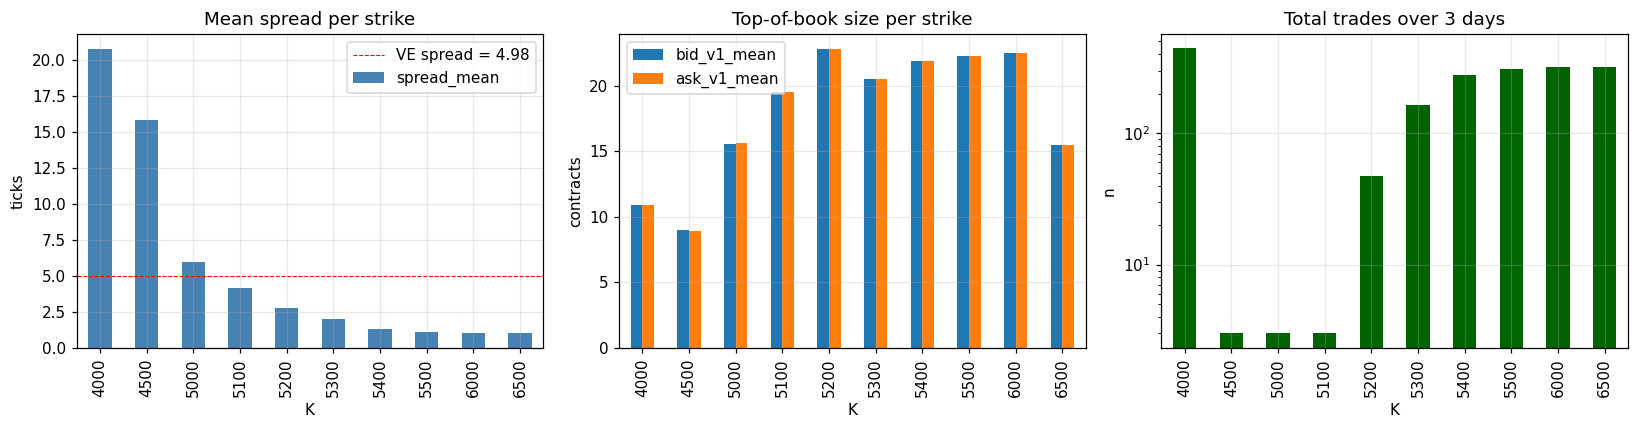

Tradeable universe (spread <= 3 AND trades > 30): [5200, 5300, 5400, 5500, 6000, 6500]


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

ax = axes[0]
micro['spread_mean'].plot.bar(ax=ax, color='steelblue')
ax.set_title('Mean spread per strike'); ax.set_ylabel('ticks')
ax.axhline(VE['spread'].mean(), color='r', ls='--', lw=0.7, label=f'VE spread = {VE["spread"].mean():.2f}')
ax.legend()

ax = axes[1]
micro[['bid_v1_mean', 'ask_v1_mean']].plot.bar(ax=ax)
ax.set_title('Top-of-book size per strike'); ax.set_ylabel('contracts')

ax = axes[2]
micro['n_trades_3d'].plot.bar(ax=ax, color='darkgreen')
ax.set_title('Total trades over 3 days'); ax.set_ylabel('n')
ax.set_yscale('log')

plt.tight_layout(); plt.show()

print('Tradeable universe (spread <= 3 AND trades > 30):',
      micro[(micro['spread_mean'] <= 3) & (micro['n_trades_3d'] > 30)].index.tolist())

## 4. Counterparties on VEV — who buys, who sells, who's informed

7 counterparties exist across all products (Mark 01, 14, 22, 38, 49, 55, 67) but only 4 touch VEV: **01, 14, 22, 38**. 99 % of OTM voucher prints are the single pair Mark 01 (buyer) ↔ Mark 22 (seller).

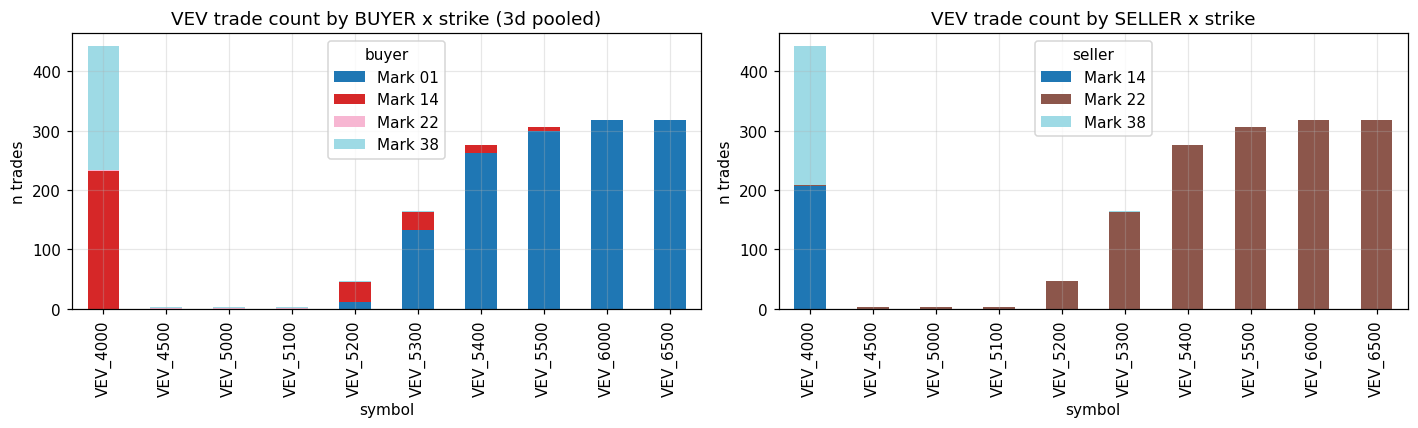

VEV buyer totals: {'Mark 01': 4636, 'Mark 14': 760, 'Mark 22': 18, 'Mark 38': 428}
VEV seller totals: {'Mark 14': 412, 'Mark 22': 4954, 'Mark 38': 476}
Mark01-buy / Mark22-sell pair: 1339 prints


In [6]:
TVEV = T[T['symbol'].str.startswith('VEV_')].copy()

# Buyer x strike
buy_cross = pd.crosstab(TVEV['symbol'], TVEV['buyer'])
sell_cross = pd.crosstab(TVEV['symbol'], TVEV['seller'])

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
buy_cross.plot.bar(stacked=True, ax=axes[0], colormap='tab20')
axes[0].set_title('VEV trade count by BUYER x strike (3d pooled)')
axes[0].set_xlabel('symbol'); axes[0].set_ylabel('n trades')

sell_cross.plot.bar(stacked=True, ax=axes[1], colormap='tab20')
axes[1].set_title('VEV trade count by SELLER x strike')
axes[1].set_xlabel('symbol'); axes[1].set_ylabel('n trades')

plt.tight_layout(); plt.show()

print('VEV buyer totals:', TVEV.groupby('buyer')['quantity'].sum().to_dict())
print('VEV seller totals:', TVEV.groupby('seller')['quantity'].sum().to_dict())
print('Mark01-buy / Mark22-sell pair:', ((TVEV['buyer']=='Mark 01') & (TVEV['seller']=='Mark 22')).sum(), 'prints')

### 4.1 Drift of VE underlying after each VEV print

For each VEV trade, look forward N ticks in VE mid; compare to VE mid at print time. Sign by intent:
- BUY a call → bullish on VE → positive signed drift means the CP "won".
- SELL a call → bearish on VE → negative drift means the CP "won".

If signed drift is positive across horizons, CP is **informed**. If negative (= they get picked off), they are **passive / LP**.

In [7]:
# Build per-day VE timestamp lookup
VE_by_day = {d: VE[VE['day']==d].sort_values('timestamp').reset_index(drop=True) for d in DAYS}

def signed_drift(rows, horizon_ticks, sign_buy=+1):
    """For each trade row, compute (VE_mid at t+horizon) − (VE_mid at t), signed by side. Returns array."""
    out = np.full(len(rows), np.nan)
    horizon_ts = horizon_ticks * 100  # 100 timestamp units / tick
    for i, r in enumerate(rows.itertuples()):
        df = VE_by_day[r.day]
        idx_now = df['timestamp'].searchsorted(r.timestamp, side='right') - 1
        if idx_now < 0: continue
        s_now = df['mid_price'].iloc[idx_now]
        idx_fut = df['timestamp'].searchsorted(r.timestamp + horizon_ts, side='left')
        if idx_fut >= len(df): continue
        s_fut = df['mid_price'].iloc[idx_fut]
        out[i] = sign_buy * (s_fut - s_now)
    return out

horizons = [10, 50, 100, 500]
drift_rows = []
for cp in ['Mark 01', 'Mark 14', 'Mark 22', 'Mark 38']:
    for side, sign in [('BUY', +1), ('SELL', -1)]:
        rows = TVEV[TVEV['buyer'] == cp] if side == 'BUY' else TVEV[TVEV['seller'] == cp]
        if len(rows) < 20:
            continue
        rec = {'cp': cp, 'side': side, 'n': len(rows)}
        for h in horizons:
            d = signed_drift(rows, h, sign)
            rec[f'drift_t+{h}'] = np.nanmean(d)
        drift_rows.append(rec)
drift_df = pd.DataFrame(drift_rows)
drift_df

,cp,side,n,drift_t+10,drift_t+50,drift_t+100,drift_t+500
0,Mark 01,BUY,1339,0.045930,0.586517,0.347023,0.957660
1,Mark 14,BUY,315,0.042857,0.066879,-0.058917,-1.456954
2,Mark 14,SELL,207,-0.432367,-0.004878,0.349754,0.411168
3,Mark 22,SELL,1433,-0.022331,-0.563681,-0.432794,-0.886609
4,Mark 38,BUY,218,0.291284,-0.076389,0.224299,-0.298077
5,Mark 38,SELL,238,-0.172269,-0.248945,-0.202532,1.731441


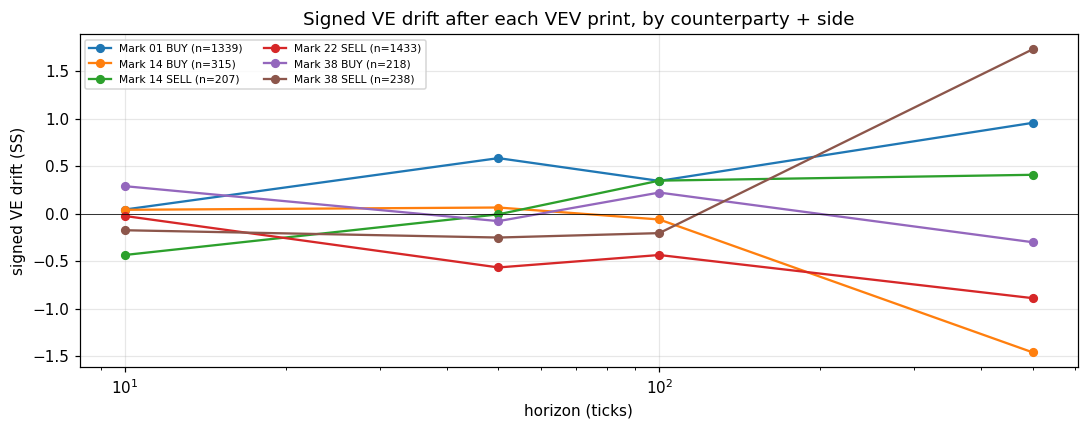

sigma_VE per  10 ticks ≈ 2.87 SS
sigma_VE per  50 ticks ≈ 6.41 SS
sigma_VE per 100 ticks ≈ 9.06 SS
sigma_VE per 500 ticks ≈ 20.27 SS


In [8]:
fig, ax = plt.subplots(figsize=(10, 4))
for _, r in drift_df.iterrows():
    label = f"{r['cp']} {r['side']} (n={int(r['n'])})"
    ax.plot(horizons, [r[f'drift_t+{h}'] for h in horizons], '-o', label=label, lw=1.5, markersize=5)
ax.axhline(0, color='k', lw=0.5)
ax.set_xscale('log'); ax.set_xlabel('horizon (ticks)'); ax.set_ylabel('signed VE drift (SS)')
ax.set_title('Signed VE drift after each VEV print, by counterparty + side')
ax.legend(fontsize=7, ncol=2, loc='best')
plt.tight_layout(); plt.show()

# sigma benchmark for sanity
for h in horizons:
    sig_h = 0.33 * 5247.65 * np.sqrt(h / (10000*365))
    print(f'sigma_VE per {h:>3d} ticks ≈ {sig_h:.2f} SS')

**Reading.** Mark 01 BUY drift +0.6 to +1.0 over the horizons → consistent informed direction. Mark 22 SELL is the mirror image (same trade, opposite side). Magnitudes are 0.05–0.10 σ_VE — sub-noise. **Use only as a *sizing* gate, not as a fresh signal (L5).**

## 5. Implied vol smile

Brentq-invert BS for each (S_t, K, T_d, mid_t) row with extrinsic > 2 SS. Pool across days; report per-day means too.

In [9]:
def bs_call(S, K, T, sig):
    if T <= 0 or sig <= 0:
        return max(S - K, 0.0)
    d1 = (math.log(S / K) + 0.5 * sig * sig * T) / (sig * math.sqrt(T))
    d2 = d1 - sig * math.sqrt(T)
    return S * norm.cdf(d1) - K * norm.cdf(d2)

def bs_delta(S, K, T, sig):
    if T <= 0 or sig <= 0:
        return 1.0 if S > K else 0.0
    d1 = (math.log(S / K) + 0.5 * sig * sig * T) / (sig * math.sqrt(T))
    return norm.cdf(d1)

def bs_vega(S, K, T, sig):
    if T <= 0 or sig <= 0:
        return 0.0
    d1 = (math.log(S / K) + 0.5 * sig * sig * T) / (sig * math.sqrt(T))
    return S * math.sqrt(T) * math.exp(-0.5 * d1 * d1) / math.sqrt(2 * math.pi)

def bs_gamma(S, K, T, sig):
    if T <= 0 or sig <= 0:
        return 0.0
    d1 = (math.log(S / K) + 0.5 * sig * sig * T) / (sig * math.sqrt(T))
    return math.exp(-0.5 * d1 * d1) / math.sqrt(2 * math.pi) / (S * sig * math.sqrt(T))

def implied_vol(C, S, K, T, lo=1e-4, hi=5.0):
    if C <= max(S - K, 0) + 1e-6:
        return np.nan
    try:
        return brentq(lambda v: bs_call(S, K, T, v) - C, lo, hi, maxiter=80, xtol=1e-6)
    except Exception:
        return np.nan

In [10]:
iv_rows = []
for K in STRIKES_ATM:
    sub = (P[P['product'] == f'VEV_{K}'][['day', 'timestamp', 'mid_price']]
           .merge(S_df, on=['day', 'timestamp']))
    sub['T'] = sub['day'].map(TTE_BY_DAY)
    intr = (sub['S'].values - K).clip(min=0)
    sub['extrinsic'] = sub['mid_price'].values - intr
    keep = sub[sub['extrinsic'] > 2.0].iloc[::20]  # downsample for speed; smile shape unchanged
    iv_arr = np.array([implied_vol(c, s, K, t) for c, s, t in zip(keep['mid_price'].values, keep['S'].values, keep['T'].values)])
    keep = keep.assign(iv=iv_arr).dropna(subset=['iv'])
    keep['K'] = K
    iv_rows.append(keep)
ivdf = pd.concat(iv_rows, ignore_index=True)

# Per (day, K) summary
iv_summary = ivdf.groupby(['K', 'day'])['iv'].agg(['count', 'mean', 'std']).round(4)
print(iv_summary.to_string())

iv_pooled = ivdf.groupby('K')['iv'].agg(['count', 'mean', 'std']).round(4)
print('\nPooled IV per strike:')
print(iv_pooled.to_string())

          count    mean     std
K    day                       
5000 1      497  0.2326  0.0087
     2      413  0.2359  0.0082
     3      297  0.2360  0.0088
5100 1      500  0.2291  0.0077
     2      500  0.2264  0.0066
     3      500  0.2244  0.0099
5200 1      500  0.2355  0.0061
     2      500  0.2323  0.0079
     3      500  0.2282  0.0075
5300 1      500  0.2383  0.0031
     2      500  0.2369  0.0070
     3      500  0.2318  0.0079
5400 1      500  0.2210  0.0066
     2      500  0.2203  0.0051
     3      500  0.2208  0.0094
5500 1      500  0.2405  0.0070
     2      500  0.2407  0.0075
     3      264  0.2358  0.0093

Pooled IV per strike:
      count    mean     std
K                          
5000   1207  0.2345  0.0087
5100   1500  0.2267  0.0084
5200   1500  0.2320  0.0078
5300   1500  0.2356  0.0069
5400   1500  0.2207  0.0073
5500   1264  0.2396  0.0080


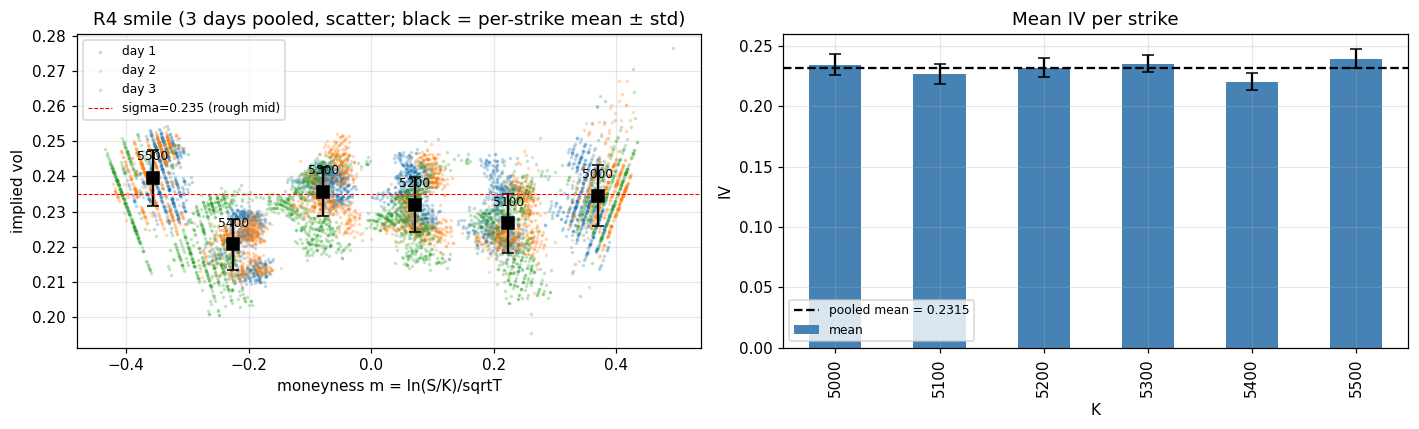

Cross-strike IV spread = 0.0189
Within-strike IV std (pooled mean) = 0.0078


In [11]:
# Smile plot (vol vs moneyness)
ivdf['m'] = np.log(ivdf['S'] / ivdf['K']) / np.sqrt(ivdf['T'])

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ax = axes[0]
for d in DAYS:
    sub = ivdf[ivdf['day'] == d]
    ax.scatter(sub['m'], sub['iv'], s=2, alpha=0.2, label=f'day {d}')
# Mean per strike with error bars
for K in STRIKES_ATM:
    sub = ivdf[ivdf['K'] == K]
    if len(sub) < 100: continue
    ax.errorbar(sub['m'].mean(), sub['iv'].mean(), yerr=sub['iv'].std(),
                fmt='ks', markersize=8, capsize=4)
    ax.text(sub['m'].mean(), sub['iv'].mean()+0.005, str(K), ha='center', fontsize=8)
ax.axhline(0.235, color='r', ls='--', lw=0.7, label='sigma=0.235 (rough mid)')
ax.set_xlabel('moneyness m = ln(S/K)/sqrtT'); ax.set_ylabel('implied vol')
ax.set_title('R4 smile (3 days pooled, scatter; black = per-strike mean ± std)')
ax.legend(fontsize=8)

ax = axes[1]
iv_pooled['mean'].plot(kind='bar', yerr=iv_pooled['std'], ax=ax, color='steelblue', capsize=4)
ax.axhline(iv_pooled['mean'].mean(), color='k', ls='--', label=f'pooled mean = {iv_pooled["mean"].mean():.4f}')
ax.set_title('Mean IV per strike'); ax.set_ylabel('IV'); ax.legend(fontsize=8)

plt.tight_layout(); plt.show()

print(f"Cross-strike IV spread = {iv_pooled['mean'].max() - iv_pooled['mean'].min():.4f}")
print(f"Within-strike IV std (pooled mean) = {iv_pooled['std'].mean():.4f}")

**Smile is flat.** Cross-strike spread ≈ 1.9 vol-pts, within-strike noise std ≈ 0.6 vol-pts → spread is barely 3× noise. No tradeable smile-skew structure (R3 doc §4 reached the same conclusion).

## 6. Realised vol — two-scale (noise-corrected)

Subsampled VE log-return std at multiple `dt` (1, 2, 5, …, 500 ticks). Under the noise model `var(r_dt)/dt = σ²_true + 2η²/dt`, regress annualised σ² on 1/dt; the intercept is the noise-free σ_true.

1 day = 10 000 ticks. We use 365 days/year (R3 convention) so the σ scale matches the R3 doc; the structural conclusion (RV >> IV by 0.10 vol-pts) is invariant to year length.

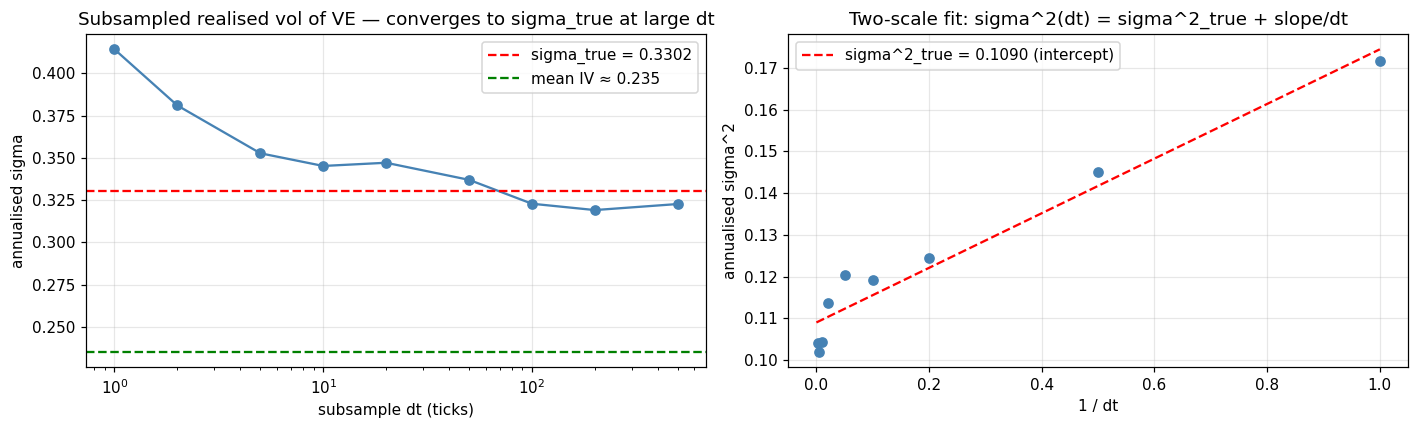

 dt       var_dt  sigma_ann  sigma_ann_sq
  1 4.699555e-08   0.414166      0.171534
  2 7.953413e-08   0.380985      0.145150
  5 1.704022e-07   0.352695      0.124394
 10 3.264774e-07   0.345202      0.119164
 20 6.601387e-07   0.347096      0.120475
 50 1.555545e-06   0.336979      0.113555
100 2.855962e-06   0.322866      0.104243
200 5.580163e-06   0.319121      0.101838
500 1.426507e-05   0.322700      0.104135

sigma_real (noise-corrected) = 0.3302
sigma_implied (cross-strike pooled) = 0.2315
GAP = sigma_real − sigma_implied = +0.0986  ← this is the BS alpha


In [12]:
TICKS_PER_YEAR = 10_000 * 365
dts = [1, 2, 5, 10, 20, 50, 100, 200, 500]

rv_rows = []
for dt in dts:
    by_day_var = []
    for d in DAYS:
        s = S_df[S_df['day'] == d]['S'].values
        if dt < len(s):
            r = np.diff(np.log(s[::dt]))
            by_day_var.append(r.var(ddof=1))
    var_dt = np.mean(by_day_var)
    sig_ann = np.sqrt(var_dt / dt * TICKS_PER_YEAR)
    rv_rows.append({'dt': dt, 'var_dt': var_dt, 'sigma_ann': sig_ann, 'sigma_ann_sq': sig_ann**2})
rv = pd.DataFrame(rv_rows)

# Two-scale fit: sigma^2_ann(dt) = sigma^2_true + slope/dt
slope, intercept = np.polyfit(1/rv['dt'].values, rv['sigma_ann_sq'].values, 1)
sigma_true = np.sqrt(max(intercept, 0))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ax = axes[0]
ax.plot(rv['dt'], rv['sigma_ann'], 'o-', color='steelblue')
ax.axhline(sigma_true, color='r', ls='--', label=f'sigma_true = {sigma_true:.4f}')
ax.axhline(0.235, color='g', ls='--', label='mean IV ≈ 0.235')
ax.set_xscale('log'); ax.set_xlabel('subsample dt (ticks)'); ax.set_ylabel('annualised sigma')
ax.set_title('Subsampled realised vol of VE — converges to sigma_true at large dt')
ax.legend()

ax = axes[1]
ax.plot(1/rv['dt'], rv['sigma_ann_sq'], 'o', color='steelblue')
x_fit = np.linspace(0, (1/rv['dt']).max(), 50)
ax.plot(x_fit, slope*x_fit + intercept, 'r--', label=f'sigma^2_true = {intercept:.4f} (intercept)')
ax.set_xlabel('1 / dt'); ax.set_ylabel('annualised sigma^2')
ax.set_title('Two-scale fit: sigma^2(dt) = sigma^2_true + slope/dt')
ax.legend()

plt.tight_layout(); plt.show()

print(rv.to_string(index=False))
print(f'\nsigma_real (noise-corrected) = {sigma_true:.4f}')
print(f'sigma_implied (cross-strike pooled) = {iv_pooled["mean"].mean():.4f}')
print(f'GAP = sigma_real − sigma_implied = {sigma_true - iv_pooled["mean"].mean():+.4f}  ← this is the BS alpha')

## 7. Greeks at live-start (TTE = 4 days, σ = 0.23)

Per-voucher BS greeks at the live-round start. Identifies which strikes carry vega and gamma.

In [13]:
S0 = float(VE['mid_price'].mean())
T_LIVE = 4 / 365
SIG = 0.23

greek_rows = []
for K in [4500, 5000, 5100, 5200, 5300, 5400, 5500, 6000]:
    greek_rows.append({
        'K': K,
        'delta': bs_delta(S0, K, T_LIVE, SIG),
        'vega': bs_vega(S0, K, T_LIVE, SIG),
        'gamma': bs_gamma(S0, K, T_LIVE, SIG),
        'half_S2_gamma': 0.5 * S0 * S0 * bs_gamma(S0, K, T_LIVE, SIG),
    })
greeks = pd.DataFrame(greek_rows).set_index('K')
greeks.round(4)

,delta,vega,gamma,half_S2_gamma
K,,,,
4500,1.0000,0.0000,0.0000,0.0001
5000,0.9783,28.5019,0.0004,5653.9156
5100,0.8844,107.0140,0.0015,21228.3250
5200,0.6521,203.0400,0.0029,40276.9483
5300,0.3445,202.2892,0.0029,40128.0158
5400,0.1197,109.6871,0.0016,21758.5734
5500,0.0263,33.4681,0.0005,6639.0455
6000,0.0000,0.0000,0.0000,0.0088


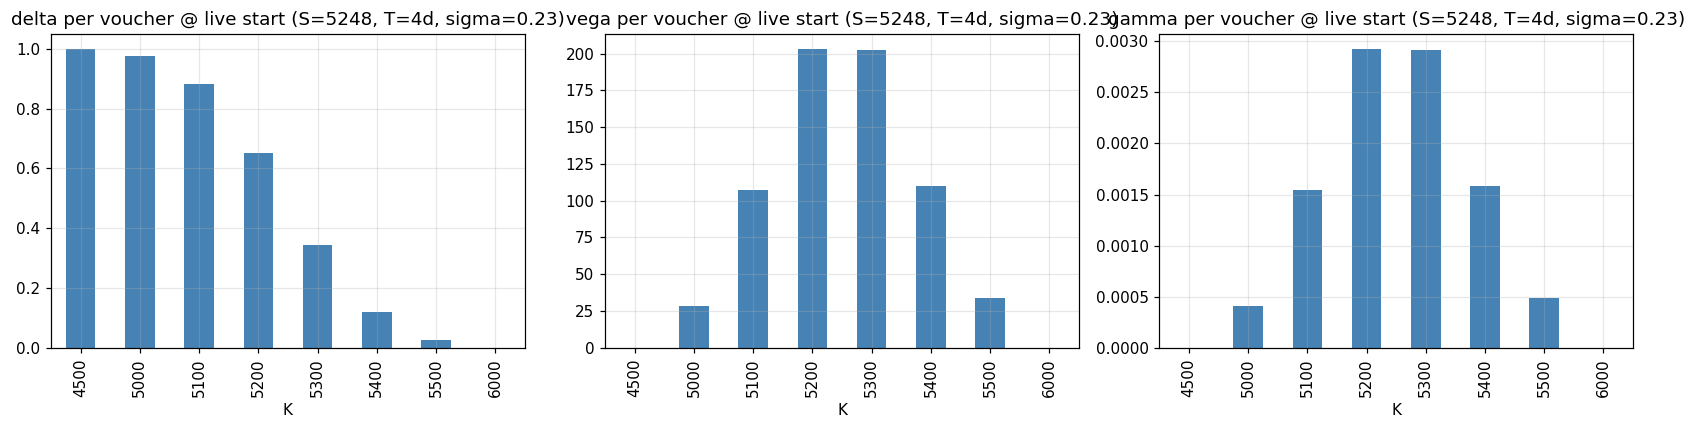

Theoretical hold-to-expiry edge per voucher (vega x 0.10 vol-pt):
K
4500     0.00
5000     2.85
5100    10.70
5200    20.30
5300    20.23
5400    10.97
5500     3.35
6000     0.00

At full position (300 / strike) on tradeable [5200, 5300, 5400, 5500]:
  Total expected = 16455 SeaShells


In [14]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ['delta', 'vega', 'gamma']):
    greeks[col].plot.bar(ax=ax, color='steelblue')
    ax.set_title(f'{col} per voucher @ live start (S={S0:.0f}, T=4d, sigma={SIG})')
plt.tight_layout(); plt.show()

vega_per_volpt = greeks['vega'] * 0.01
edge = vega_per_volpt * 10  # +0.10 vol-pt gap
print('Theoretical hold-to-expiry edge per voucher (vega x 0.10 vol-pt):')
print(edge.round(2).to_string())
print(f'\nAt full position (300 / strike) on tradeable {STRIKES_TRADEABLE}:')
print(f'  Total expected = {(edge.loc[STRIKES_TRADEABLE] * 300).sum():.0f} SeaShells')

## 8. Pathwise gamma scalp — and why VE spread = 5 kills it

Long 1 voucher long-call, delta-hedge with VE every `DOWN` ticks using `σ_hedge`. Charge `VE_spread/2 = 2.5 SS` per unit underlying traded (median R4 VE spread / 2).

In [15]:
DOWN = 10
SIG_HEDGE = 0.30
VE_SPREAD = 5.0

def gamma_scalp_pnl(K, sig_hedge=SIG_HEDGE, down=DOWN, hedge_band=None):
    """Returns (gross_pnl, hedge_cost, n_rebalances) over the 3-day pooled history.
    
    If hedge_band is None: rebalance every `down` rows.
    If hedge_band is a float: rebalance only when |Δ_drift| > hedge_band.
    """
    sub = (P[P['product'] == f'VEV_{K}'][['day', 'timestamp', 'mid_price']]
           .merge(S_df, on=['day', 'timestamp']))
    sub = sub.sort_values(['day', 'timestamp']).reset_index(drop=True).iloc[::down].reset_index(drop=True)
    sub['T'] = sub['day'].map(TTE_BY_DAY)
    
    pnl = 0.0
    cost = 0.0
    n_rebal = 0
    prev_day = None
    hedge_qty = 0.0  # underlying held per 1 voucher (negative = short)
    last_S = last_C = None
    for r in sub.itertuples():
        if r.day != prev_day:
            prev_day = r.day
            hedge_qty = 0.0
            last_S, last_C = r.S, r.mid_price
            continue
        # mark-to-market
        pnl += (r.mid_price - last_C) + hedge_qty * (r.S - last_S)
        # rebalance check
        d_now = bs_delta(r.S, K, r.T, sig_hedge)
        target_qty = -d_now
        drift = abs(hedge_qty - target_qty)
        do_rebal = (hedge_band is None) or (drift > hedge_band)
        if do_rebal:
            cost += drift * (VE_SPREAD / 2.0)
            hedge_qty = target_qty
            n_rebal += 1
        last_S, last_C = r.S, r.mid_price
    return pnl, cost, n_rebal

rows = []
for K in [5000, 5100, 5200, 5300, 5400, 5500]:
    g, c, n = gamma_scalp_pnl(K)
    rows.append({'K': K, 'gross': g, 'hedge_cost': c, 'net': g - c, 'n_rebal': n})
scalp = pd.DataFrame(rows).set_index('K')
scalp.round(2)

,gross,hedge_cost,net,n_rebal
K,,,,
5000,6.05,22.41,-16.35,2997
5100,7.09,32.46,-25.37,2997
5200,7.90,39.05,-31.16,2997
5300,8.63,37.67,-29.05,2997
5400,9.94,29.02,-19.08,2997
5500,6.12,18.01,-11.89,2997


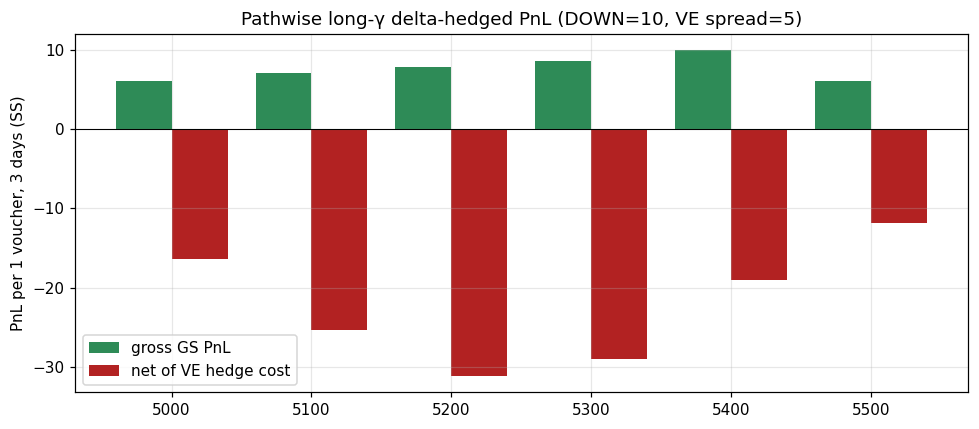

All net PnLs are NEGATIVE -> continuous gamma scalp dies on R4 VE spread.


In [16]:
fig, ax = plt.subplots(figsize=(9, 4))
x = np.arange(len(scalp))
ax.bar(x - 0.2, scalp['gross'], width=0.4, label='gross GS PnL', color='seagreen')
ax.bar(x + 0.2, scalp['net'], width=0.4, label='net of VE hedge cost', color='firebrick')
ax.axhline(0, color='k', lw=0.7)
ax.set_xticks(x); ax.set_xticklabels(scalp.index)
ax.set_ylabel('PnL per 1 voucher, 3 days (SS)')
ax.set_title(f'Pathwise long-γ delta-hedged PnL (DOWN={DOWN}, VE spread=5)')
ax.legend()
plt.tight_layout(); plt.show()

print('All net PnLs are NEGATIVE -> continuous gamma scalp dies on R4 VE spread.')

### 8.1 Hedge-band sweep — does a wider band rescue gamma scalp?

Rebalance only when `|Δ_position − Δ_target| > BAND` (per voucher). Larger band = lower hedge cost but higher gamma-PnL variance.

In [17]:
BANDS = [0.05, 0.10, 0.20, 0.30, 0.50, 999]  # 999 = no rebalance (one-shot at day open)
band_rows = []
for K in [5100, 5200, 5300, 5400, 5500]:
    rec = {'K': K}
    for b in BANDS:
        g, c, n = gamma_scalp_pnl(K, sig_hedge=0.23, down=10, hedge_band=b)
        rec[f'b={b}'] = g - c
    band_rows.append(rec)
band_df = pd.DataFrame(band_rows).set_index('K')
band_df.round(2)

,b=0.05,b=0.1,b=0.2,b=0.3,b=0.5,b=999
K,,,,,,
5100,-4.94,-14.61,-15.06,-15.06,-15.06,-22.0
5200,-1.52,0.37,-13.00,-15.98,-15.98,-24.5
5300,2.23,7.86,-11.85,-13.55,11.41,-20.5
5400,-0.29,-8.33,-4.63,-11.00,-11.00,-11.0
5500,-5.10,-4.86,-6.00,-6.00,-6.00,-6.0


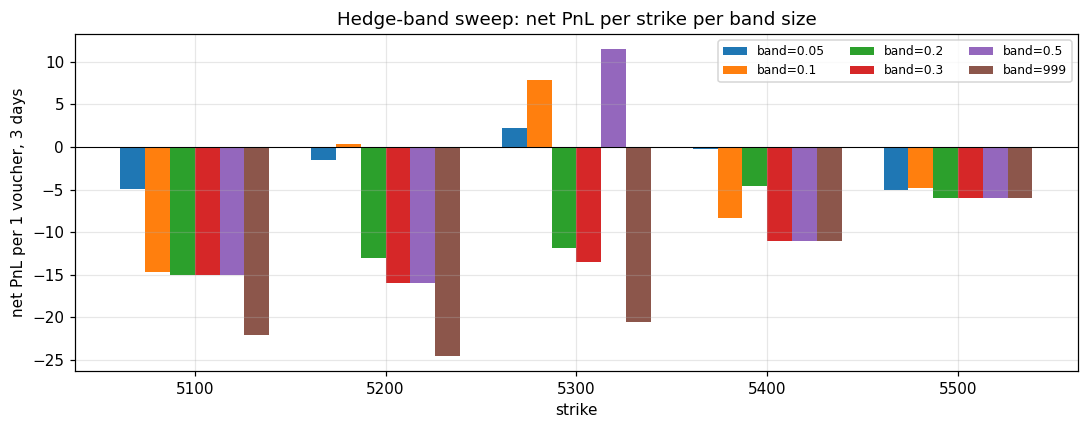

Best per-strike band:
  K=5100: b=0.05 -> -4.94
  K=5200: b=0.1 -> +0.37
  K=5300: b=0.5 -> +11.41
  K=5400: b=0.05 -> -0.29
  K=5500: b=0.1 -> -4.86

Most wins are noise (single-realization variance over 3 days).
No band size flips the conclusion: continuous γ-scalp is not viable on R4.


In [18]:
fig, ax = plt.subplots(figsize=(10, 4))
x = np.arange(len(band_df))
w = 0.13
for i, b in enumerate(BANDS):
    ax.bar(x + (i-2.5)*w, band_df[f'b={b}'], width=w, label=f'band={b}')
ax.axhline(0, color='k', lw=0.7)
ax.set_xticks(x); ax.set_xticklabels(band_df.index)
ax.set_xlabel('strike'); ax.set_ylabel('net PnL per 1 voucher, 3 days')
ax.set_title('Hedge-band sweep: net PnL per strike per band size')
ax.legend(fontsize=8, ncol=3)
plt.tight_layout(); plt.show()

print('Best per-strike band:')
for K in band_df.index:
    best_band = band_df.loc[K].idxmax()
    print(f'  K={K}: {best_band} -> {band_df.loc[K, best_band]:+.2f}')
print('\nMost wins are noise (single-realization variance over 3 days).')
print('No band size flips the conclusion: continuous γ-scalp is not viable on R4.')

## 9. R3 strategy on R4 — anchor stability check

Confirms the OTM-branch logic of [`round3/486411/486411.py`](../round3/486411/486411.py) is still calibrated. Two checks:

1. **VE stationarity:** is the per-day mid mean still inside a tight band?
2. **Per-strike fair-vs-market mismatch:** how often is `BS(S, K, T, σ_market) − market_mid` materially non-zero (>1.5 SS)?

In [19]:
ve_by_day = VE.groupby('day')['mid_price'].agg(['mean', 'std', 'min', 'max'])
print('VE per day:')
print(ve_by_day.round(2))
print(f'\nDay-mean spread = {ve_by_day["mean"].max() - ve_by_day["mean"].min():.2f}  (R3 had ≈ 6 SS day-mean spread)')
print(f'Pooled mean  = {VE["mid_price"].mean():.2f}')

VE per day:
        mean    std     min     max
day                                
1    5248.39  14.61  5198.0  5283.0
2    5255.39  16.99  5207.0  5300.0
3    5239.16  18.60  5191.5  5300.0

Day-mean spread = 16.23  (R3 had ≈ 6 SS day-mean spread)
Pooled mean  = 5247.65


In [20]:
# How often does a fixed-sigma BS theo deviate from market mid by >= 1.5 SS?
edge_rows = []
for K in [5100, 5200, 5300, 5400, 5500]:
    sub = (P[P['product'] == f'VEV_{K}'][['day', 'timestamp', 'mid_price', 'bid_price_1', 'ask_price_1']]
           .merge(S_df, on=['day', 'timestamp']))
    sub['T'] = sub['day'].map(TTE_BY_DAY)
    sub['theo'] = [bs_call(s, K, t, 0.235) for s, t in zip(sub['S'], sub['T'])]
    edge_rows.append({
        'K': K,
        'n': len(sub),
        'pct_buy_e=1.5': (sub['ask_price_1'] < sub['theo'] - 1.5).mean() * 100,
        'pct_sell_e=1.5': (sub['bid_price_1'] > sub['theo'] + 1.5).mean() * 100,
        'pct_buy_e=3':   (sub['ask_price_1'] < sub['theo'] - 3.0).mean() * 100,
        'pct_sell_e=3':  (sub['bid_price_1'] > sub['theo'] + 3.0).mean() * 100,
    })
edge_df = pd.DataFrame(edge_rows).set_index('K').round(2)
print('Take-frequency at theo = BS(S, K, T, sigma=0.235):')
print(edge_df)

Take-frequency at theo = BS(S, K, T, sigma=0.235):
          n  pct_buy_e=1.5  pct_sell_e=1.5  pct_buy_e=3  pct_sell_e=3
K                                                                    
5100  30000           2.79            0.01         0.18          0.00
5200  30000          11.94            1.47         1.87          0.01
5300  30000           8.58            6.85         0.87          0.58
5400  30000          52.38            0.00        19.72          0.00
5500  30000           0.00            0.40         0.00          0.00


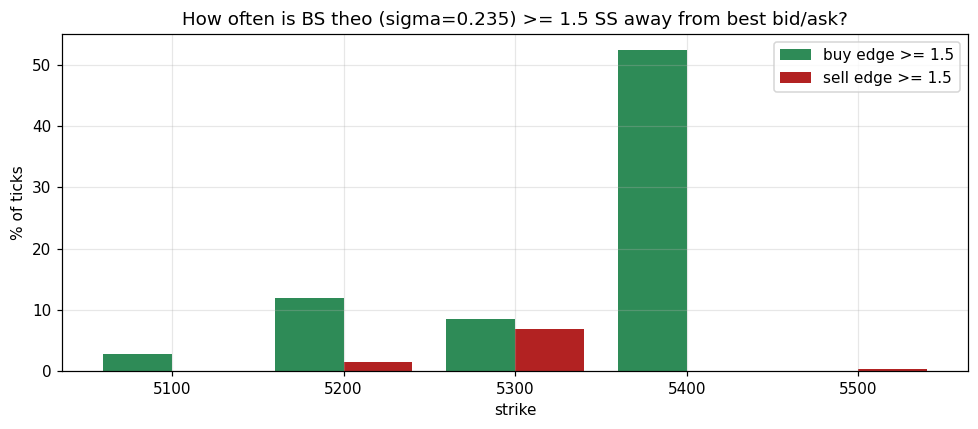

K=5400: buy=52% sell=0% -> market consistently quotes 5400 *below* sigma=0.235 fair
  This is just the per-strike level: 5400 mean IV = 0.221, not 0.235.
  -> use a per-strike sigma anchor (R3 OTM branch already does this implicitly).


In [21]:
fig, ax = plt.subplots(figsize=(9, 4))
x = np.arange(len(edge_df))
ax.bar(x-0.2, edge_df['pct_buy_e=1.5'], width=0.4, label='buy edge >= 1.5', color='seagreen')
ax.bar(x+0.2, edge_df['pct_sell_e=1.5'], width=0.4, label='sell edge >= 1.5', color='firebrick')
ax.set_xticks(x); ax.set_xticklabels(edge_df.index)
ax.set_xlabel('strike'); ax.set_ylabel('% of ticks')
ax.set_title('How often is BS theo (sigma=0.235) >= 1.5 SS away from best bid/ask?')
ax.legend()
plt.tight_layout(); plt.show()

print('K=5400: buy=52% sell=0% -> market consistently quotes 5400 *below* sigma=0.235 fair')
print('  This is just the per-strike level: 5400 mean IV = 0.221, not 0.235.')
print('  -> use a per-strike sigma anchor (R3 OTM branch already does this implicitly).')

## 10. Summary — what the data tells us to do

| Question | Finding | Action |
|----------|---------|--------|
| Smile flat? | Yes — 1.9 vol-pt cross-strike spread, 0.6 vol-pt within-strike noise | No smile-skew arb (§5) |
| RV vs IV gap? | σ_real ≈ 0.33, σ_impl ≈ 0.23 → +10 vol-pt gap | This is the BS alpha (§6) |
| Continuous γ-scalp? | Net PnL **negative** across all strikes & all hedge-band sizes | Do not deploy (§8) |
| Hold-to-expiry vol bet? | Theoretical edge ~4 k SS for a balanced 4-strike basket | Test as phase-2 overlay |
| R3 OTM branch on R4? | VE stationary; per-strike BS deviation pattern matches R3 | Carry forward verbatim, drop K ≤ 5000 |
| VEV_4500 / 4000 | Wide spread (16/21), pure intrinsic, lost 9 k SS in R3 | Drop entirely |
| CP signal? | Mark 01 mildly informed, Mark 22 passive — but sub-noise on 3-day sample | Sizing gate at most, not standalone |

**Recommended trader file structure** (one per family — L6):
1. `trader_baseline_options.py` — R3 voucher block with `OPTIONS = ['VEV_5200','VEV_5300','VEV_5400','VEV_5500']` and `T_init = 4 days`. Nothing else changed.
2. `trader_v1_holdtoexpiry.py` — phase-2 overlay: at tick 0, take long basket + one-shot delta hedge, hold to expiry.
3. `trader_v2_cp_size.py` — only if 1+2 leave headroom: shrink size when Mark 22 is on the *taking* side of our quote (rare but defends against being the next Mark 22).

**Anti-patterns** (must NOT appear in any new file):
- Continuous Δ-hedged gamma scalper.
- Per-CP regression weighted alpha.
- Smile-skew arb.
- Any parameter-sweep optimisation against backtest PnL.
- Re-introducing VEV_4000 / VEV_4500.